# **Aula 1 -  Análise de Dados com Pandas - 27/01**

In [54]:
import pandas as pd

df = pd.read_csv("https://raw.githubusercontent.com/guilhermeonrails/data-jobs/refs/heads/main/salaries.csv")

df.head()

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2025.0,SE,FT,Solutions Engineer,214000,USD,214000,US,100,US,M
1,2025.0,SE,FT,Solutions Engineer,136000,USD,136000,US,100,US,M
2,2025.0,MI,FT,Data Engineer,158800,USD,158800,AU,0,AU,M
3,2025.0,MI,FT,Data Engineer,139200,USD,139200,AU,0,AU,M
4,2025.0,EN,FT,Data Engineer,90000,USD,90000,US,0,US,M


In [55]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 133349 entries, 0 to 133348
Data columns (total 11 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   work_year           133339 non-null  float64
 1   experience_level    133349 non-null  object 
 2   employment_type     133349 non-null  object 
 3   job_title           133349 non-null  object 
 4   salary              133349 non-null  int64  
 5   salary_currency     133349 non-null  object 
 6   salary_in_usd       133349 non-null  int64  
 7   employee_residence  133349 non-null  object 
 8   remote_ratio        133349 non-null  int64  
 9   company_location    133349 non-null  object 
 10  company_size        133349 non-null  object 
dtypes: float64(1), int64(3), object(7)
memory usage: 11.2+ MB


In [56]:
df.describe()

,work_year,salary,salary_in_usd,remote_ratio
count,133339.000000,1.333490e+05,133349.000000,133349.000000
mean,2024.358770,1.632833e+05,157617.272098,20.905669
std,0.680627,2.173860e+05,74288.363097,40.590044
min,2020.000000,1.400000e+04,15000.000000,0.000000
25%,2024.000000,1.060200e+05,106000.000000,0.000000
50%,2024.000000,1.470000e+05,146206.000000,0.000000
75%,2025.000000,1.990000e+05,198000.000000,0.000000
max,2025.000000,3.040000e+07,800000.000000,100.000000


In [57]:
print(f'Linhas: {df.shape[0]}\nColunas: {df.shape[1]}')

Linhas: 133349
Colunas: 11


In [58]:
df.columns

Index(['work_year', 'experience_level', 'employment_type', 'job_title',
       'salary', 'salary_currency', 'salary_in_usd', 'employee_residence',
       'remote_ratio', 'company_location', 'company_size'],
      dtype='object')

In [59]:
colunas_renomeadas = {
    "work_year": "ano",
    "experience_level": "senioridade",
    "employment_type": "contrato",
    "job_title": "cargo",
    "salary": "salario",
    "salary_currency": "moeda",
    "salary_in_usd": "usd",
    "employee_residence": "residencia" ,
    "remote_ratio": "remoto",
    "company_location": "empresa",
    "company_size": "tamanho_empresa"
}

df.rename(columns=colunas_renomeadas, inplace=True);

df.head()

,ano,senioridade,contrato,cargo,salario,moeda,usd,residencia,remoto,empresa,tamanho_empresa
0,2025.0,SE,FT,Solutions Engineer,214000,USD,214000,US,100,US,M
1,2025.0,SE,FT,Solutions Engineer,136000,USD,136000,US,100,US,M
2,2025.0,MI,FT,Data Engineer,158800,USD,158800,AU,0,AU,M
3,2025.0,MI,FT,Data Engineer,139200,USD,139200,AU,0,AU,M
4,2025.0,EN,FT,Data Engineer,90000,USD,90000,US,0,US,M


In [60]:
df['senioridade'].value_counts()

,count
senioridade,
SE,77241
MI,40465
EN,12443
EX,3200




*   **SE (Senior-level):** Existem 77.241 entradas com nível de experiência sênior.
*   **MI (Mid-level):** Existem 40.465 entradas com nível de experiência médio.
*   **EN (Entry-level):** Existem 12.443 entradas com nível de experiência inicial.
*   **EX (Executive-level):** Existem 3.200 entradas com nível de experiência executivo.

Isso indica que a maioria dos dados representa indivíduos com experiência de nível sênior.

In [61]:
df["contrato"].value_counts()

,count
contrato,
FT,132563
CT,394
PT,376
FL,16



*   **FT (Full-time):** Existem 132.563 entradas com contratos de tempo integral.
*   **CT (Contract):** Existem 394 entradas com contratos de tipo 'Contract'.
*   **PT (Part-time):** Existem 376 entradas com contratos de tempo parcial.
*   **FL (Freelance):** Existem 16 entradas com contratos de tipo 'Freelance'.

Isso indica que a grande maioria dos registros no dataset são de funcionários em tempo integral.

In [62]:
df['remoto'].value_counts()

,count
remoto,
0,105312
100,27718
50,319




*   **0 (Presencial):** Existem 105.312 registros de funcionários que trabalham de forma totalmente presencial.
*   **100 (Remoto):** Existem 27.718 registros de funcionários que trabalham de forma totalmente remota.
*   **50 (Híbrido):** Existem 319 registros de funcionários que trabalham em um modelo híbrido (parcialmente remoto, parcialmente presencial).

Isso mostra que a grande maioria dos funcionários no dataset trabalha em regime presencial.

In [63]:
df['tamanho_empresa'].value_counts()

,count
tamanho_empresa,
M,129561
L,3574
S,214




*   **M (Médio):** Existem 129.561 registros de empresas de tamanho médio.
*   **L (Grande):** Existem 3.574 registros de empresas de tamanho grande.
*   **S (Pequeno):** Existem 214 registros de empresas de tamanho pequeno.

Isso indica que a grande maioria das empresas no dataset são de tamanho médio.

In [64]:
senioridade_map = {
    "SE": "senior",
    "MI": "pleno",
    "EN": "junior",
    "EX": "executivo"
}

df['senioridade'] = df['senioridade'].replace(senioridade_map)

df.head()

,ano,senioridade,contrato,cargo,salario,moeda,usd,residencia,remoto,empresa,tamanho_empresa
0,2025.0,senior,FT,Solutions Engineer,214000,USD,214000,US,100,US,M
1,2025.0,senior,FT,Solutions Engineer,136000,USD,136000,US,100,US,M
2,2025.0,pleno,FT,Data Engineer,158800,USD,158800,AU,0,AU,M
3,2025.0,pleno,FT,Data Engineer,139200,USD,139200,AU,0,AU,M
4,2025.0,junior,FT,Data Engineer,90000,USD,90000,US,0,US,M


In [65]:
df["senioridade"].value_counts()

,count
senioridade,
senior,77241
pleno,40465
junior,12443
executivo,3200


In [66]:
contrado_mapa = {
    'FT': 'integral',
    'PT': 'parcial',
    'CT': 'contrato',
    'FL': 'freelancer'
}

df["contrato"] = df["contrato"].replace(contrado_mapa)

df.head()

,ano,senioridade,contrato,cargo,salario,moeda,usd,residencia,remoto,empresa,tamanho_empresa
0,2025.0,senior,integral,Solutions Engineer,214000,USD,214000,US,100,US,M
1,2025.0,senior,integral,Solutions Engineer,136000,USD,136000,US,100,US,M
2,2025.0,pleno,integral,Data Engineer,158800,USD,158800,AU,0,AU,M
3,2025.0,pleno,integral,Data Engineer,139200,USD,139200,AU,0,AU,M
4,2025.0,junior,integral,Data Engineer,90000,USD,90000,US,0,US,M


In [67]:
df['contrato'].value_counts()


,count
contrato,
integral,132563
contrato,394
parcial,376
freelancer,16


In [68]:
tamamho_empresa_map = {
    "M": "média",
    "L": "grande",
    "S": "pequena"
}

df['tamanho_empresa'] = df["tamanho_empresa"].replace(tamamho_empresa_map)

df.head()

,ano,senioridade,contrato,cargo,salario,moeda,usd,residencia,remoto,empresa,tamanho_empresa
0,2025.0,senior,integral,Solutions Engineer,214000,USD,214000,US,100,US,média
1,2025.0,senior,integral,Solutions Engineer,136000,USD,136000,US,100,US,média
2,2025.0,pleno,integral,Data Engineer,158800,USD,158800,AU,0,AU,média
3,2025.0,pleno,integral,Data Engineer,139200,USD,139200,AU,0,AU,média
4,2025.0,junior,integral,Data Engineer,90000,USD,90000,US,0,US,média


In [69]:
df["tamanho_empresa"].value_counts()

,count
tamanho_empresa,
média,129561
grande,3574
pequena,214


In [70]:
trabalho_mapa = {
    0: "presencial",
    100: "remoto",
    50: "hibrido"
}


df['remoto'] = df["remoto"].replace(trabalho_mapa)

df.head()

,ano,senioridade,contrato,cargo,salario,moeda,usd,residencia,remoto,empresa,tamanho_empresa
0,2025.0,senior,integral,Solutions Engineer,214000,USD,214000,US,remoto,US,média
1,2025.0,senior,integral,Solutions Engineer,136000,USD,136000,US,remoto,US,média
2,2025.0,pleno,integral,Data Engineer,158800,USD,158800,AU,presencial,AU,média
3,2025.0,pleno,integral,Data Engineer,139200,USD,139200,AU,presencial,AU,média
4,2025.0,junior,integral,Data Engineer,90000,USD,90000,US,presencial,US,média


In [71]:
df["remoto"].value_counts()

,count
remoto,
presencial,105312
remoto,27718
hibrido,319


In [73]:
df.head()

,ano,senioridade,contrato,cargo,salario,moeda,usd,residencia,remoto,empresa,tamanho_empresa
0,2025.0,senior,integral,Solutions Engineer,214000,USD,214000,US,remoto,US,média
1,2025.0,senior,integral,Solutions Engineer,136000,USD,136000,US,remoto,US,média
2,2025.0,pleno,integral,Data Engineer,158800,USD,158800,AU,presencial,AU,média
3,2025.0,pleno,integral,Data Engineer,139200,USD,139200,AU,presencial,AU,média
4,2025.0,junior,integral,Data Engineer,90000,USD,90000,US,presencial,US,média


In [74]:
df.describe(include='object')

,senioridade,contrato,cargo,moeda,residencia,remoto,empresa,tamanho_empresa
count,133349,133349,133349,133349,133349,133349,133349,133349
unique,4,4,390,26,102,3,95,3
top,senior,integral,Data Scientist,USD,US,presencial,US,média
freq,77241,132563,17314,126140,119579,105312,119641,129561


1. Qual o nível de experiência mais comum na base de dados?
2. Qual é o tipo de contrato mais frequente?
3. Qual o cargo mais frequente na amostra?
4. De qual país são a maioria dos
profissionais da base?
5. Qual é o país onde mais empresas da amostra estão sediadas?
6. Qual o regime de trabalho mais comum?
7. Qual é o tamanho mais comum das empresas na amostra?





# **Aula 2 - Preparação e limpeza dos Dados - 28/01**

In [75]:
df.isnull()

,ano,senioridade,contrato,cargo,salario,moeda,usd,residencia,remoto,empresa,tamanho_empresa
0,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...
133344,False,False,False,False,False,False,False,False,False,False,False
133345,False,False,False,False,False,False,False,False,False,False,False
133346,False,False,False,False,False,False,False,False,False,False,False
133347,False,False,False,False,False,False,False,False,False,False,False


In [76]:
df.isnull().sum()

,0
ano,10
senioridade,0
contrato,0
cargo,0
salario,0
moeda,0
usd,0
residencia,0
remoto,0
empresa,0


In [77]:
df['ano'].unique()

array([2025.,   nan, 2024., 2022., 2023., 2020., 2021.])

In [78]:
df[df.isnull().any(axis=1)]
# O código df[df.isnull().any(axis=1)] é usado para identificar e exibir todas as linhas (registros) em seu DataFrame df que contêm pelo menos um valor nulo

,ano,senioridade,contrato,cargo,salario,moeda,usd,residencia,remoto,empresa,tamanho_empresa
5588,NaN,senior,integral,Product Manager,184500,USD,184500,US,presencial,US,média
59692,NaN,pleno,integral,Engineer,110000,USD,110000,DE,presencial,DE,média
59710,NaN,junior,integral,Data Scientist,208800,USD,208800,US,presencial,US,média
59759,NaN,senior,integral,Software Engineer,135000,USD,135000,US,presencial,US,média
59789,NaN,senior,integral,Engineer,112000,USD,112000,US,presencial,US,média
131000,NaN,senior,integral,Machine Learning Engineer,163800,USD,163800,US,presencial,US,média
131006,NaN,senior,integral,Data Analytics Manager,204500,USD,204500,US,presencial,US,média
133054,NaN,junior,integral,Data Scientist,40000,USD,40000,JP,remoto,MY,grande
133281,NaN,pleno,integral,Machine Learning Engineer,180000,PLN,46597,PL,remoto,PL,grande
133317,NaN,pleno,integral,Data Scientist,130000,USD,130000,US,hibrido,US,grande


In [84]:
import numpy as np


df_salario = pd.DataFrame({
    'nome': ["Ana", "Bruno", "Carlos", "Daniele", "Val"],
    'salario': [4000, np.nan, 5000, np.nan, 100000]
})

# Cria uma coluna nova
df_salario['salario_media'] = df_salario['salario'].fillna(df_salario['salario'].mean().round(2))

df_salario['salario_mediana'] = df_salario['salario'].fillna(df_salario['salario'].median())

df_salario.head()

,nome,salario,salario_media,salario_mediana
0,Ana,4000.0,4000.00,4000.0
1,Bruno,NaN,36333.33,5000.0
2,Carlos,5000.0,5000.00,5000.0
3,Daniele,NaN,36333.33,5000.0
4,Val,100000.0,100000.00,100000.0


In [86]:
df_temperaturas = pd.DataFrame({
    "Dia": ["Segunda", "Terça", "Quarta", "Quinta", "Sexta"],
    "Temperatura": [30, np.nan, np.nan, 28, 27]
})

df_temperaturas['Temperatura_media'] = df_temperaturas['Temperatura'].fillna(df_temperaturas['Temperatura'].mean())

df_temperaturas.head()

,Dia,Temperatura,Temperatura_media
0,Segunda,30.0,30.000000
1,Terça,NaN,28.333333
2,Quarta,NaN,28.333333
3,Quinta,28.0,28.000000
4,Sexta,27.0,27.000000


In [88]:
df_cidades = pd.DataFrame({
    "Nomes": ["Ana", "Bruno", "Carlos", "Daniele", "Val","Thais"],
    "Cidade": ["São Paulo", "Rio de Janeiro", "Belo Horizonte", "Porto Alegre", "Curitiba", np.nan],

})


df_cidades["cidade preenchida"] = df_cidades["Cidade"].fillna("Desconhecida")

df_cidades.tail()

,Nomes,Cidade,cidade preenchida
1,Bruno,Rio de Janeiro,Rio de Janeiro
2,Carlos,Belo Horizonte,Belo Horizonte
3,Daniele,Porto Alegre,Porto Alegre
4,Val,Curitiba,Curitiba
5,Thais,NaN,Desconhecida


In [89]:
df_limpo = df.dropna()

### Explicação de `fillna()` e `dropna()`

Os métodos `fillna()` e `dropna()` são ferramentas essenciais no Pandas para lidar com valores ausentes (`NaN`).

**1. `fillna()` (Preencher valores nulos)**

O método `fillna()` é usado para preencher os valores `NaN` com um valor específico que você define. Isso é útil quando você não quer perder dados, mas precisa substituir os valores ausentes por algo significativo.

**Exemplos no seu código:**

*   **Preenchendo com a média ou mediana:**
    No `df_salario` e `df_temperaturas`, os valores `NaN` foram preenchidos com a média ou mediana dos valores existentes na coluna. Por exemplo:
    ```python
    df_salario['salario_media'] = df_salario['salario'].fillna(df_salario['salario'].mean().round(2))
    df_temperaturas['Temperatura_media'] = df_temperaturas['Temperatura'].fillna(df_temperaturas['Temperatura'].mean())
    ```
    Esta é uma estratégia comum para dados numéricos, ajudando a manter a distribuição geral dos dados.

*   **Preenchendo com um valor constante:**
    No `df_cidades`, os valores `NaN` na coluna 'Cidade' foram substituídos pela string "Desconhecida":
    ```python
    df_cidades["cidade preenchida"] = df_cidades["Cidade"].fillna("Desconhecida")
    ```
    Isso é útil para colunas categóricas ou quando um valor padrão é apropriado para indicar a ausência de informação.

**2. `dropna()` (Remover valores nulos)**

O método `dropna()` é usado para remover linhas ou colunas que contêm valores `NaN`. Isso é útil quando os valores ausentes são poucos ou não podem ser preenchidos de forma significativa, e a remoção não causaria uma perda significativa de dados ou viés na análise.

**Exemplo no seu código:**

*   **Removendo linhas com valores nulos:**
    ```python
    df_limpo = df.dropna()
    ```
    Esta linha de código cria um novo DataFrame (`df_limpo`) que contém apenas as linhas do DataFrame original `df` que **não possuem nenhum valor `NaN`** em nenhuma de suas colunas. Todas as linhas que tiverem pelo menos um valor nulo são descartadas.

In [91]:
df_limpo.isnull().sum()

,0
ano,0
senioridade,0
contrato,0
cargo,0
salario,0
moeda,0
usd,0
residencia,0
remoto,0
empresa,0


In [92]:
df_limpo.head()

,ano,senioridade,contrato,cargo,salario,moeda,usd,residencia,remoto,empresa,tamanho_empresa
0,2025.0,senior,integral,Solutions Engineer,214000,USD,214000,US,remoto,US,média
1,2025.0,senior,integral,Solutions Engineer,136000,USD,136000,US,remoto,US,média
2,2025.0,pleno,integral,Data Engineer,158800,USD,158800,AU,presencial,AU,média
3,2025.0,pleno,integral,Data Engineer,139200,USD,139200,AU,presencial,AU,média
4,2025.0,junior,integral,Data Engineer,90000,USD,90000,US,presencial,US,média


In [93]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 133349 entries, 0 to 133348
Data columns (total 11 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   ano              133339 non-null  float64
 1   senioridade      133349 non-null  object 
 2   contrato         133349 non-null  object 
 3   cargo            133349 non-null  object 
 4   salario          133349 non-null  int64  
 5   moeda            133349 non-null  object 
 6   usd              133349 non-null  int64  
 7   residencia       133349 non-null  object 
 8   remoto           133349 non-null  object 
 9   empresa          133349 non-null  object 
 10  tamanho_empresa  133349 non-null  object 
dtypes: float64(1), int64(2), object(8)
memory usage: 11.2+ MB


In [94]:
df_limpo = df_limpo.assign(ano = df_limpo['ano'].astype('int64'))

# **Aula 3 - Visualização de Dados - 29/01**

In [98]:
df_limpo.head()

,ano,senioridade,contrato,cargo,salario,moeda,usd,residencia,remoto,empresa,tamanho_empresa
0,2025,senior,integral,Solutions Engineer,214000,USD,214000,US,remoto,US,média
1,2025,senior,integral,Solutions Engineer,136000,USD,136000,US,remoto,US,média
2,2025,pleno,integral,Data Engineer,158800,USD,158800,AU,presencial,AU,média
3,2025,pleno,integral,Data Engineer,139200,USD,139200,AU,presencial,AU,média
4,2025,junior,integral,Data Engineer,90000,USD,90000,US,presencial,US,média


array([[<Axes: title={'center': 'ano'}>,
        <Axes: title={'center': 'salario'}>],
       [<Axes: title={'center': 'usd'}>, <Axes: >]], dtype=object)

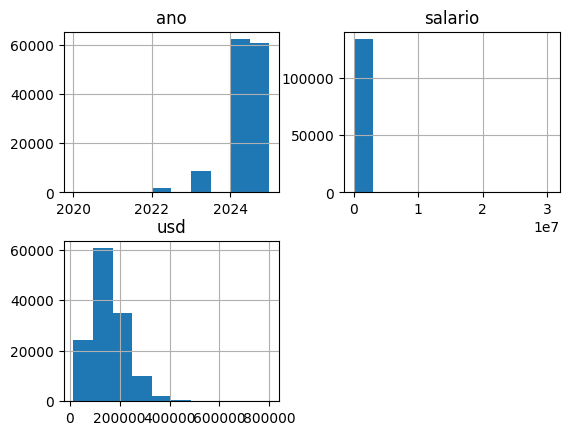

In [99]:
df_limpo.hist()

Text(0.5, 1.0, 'Senioridade')

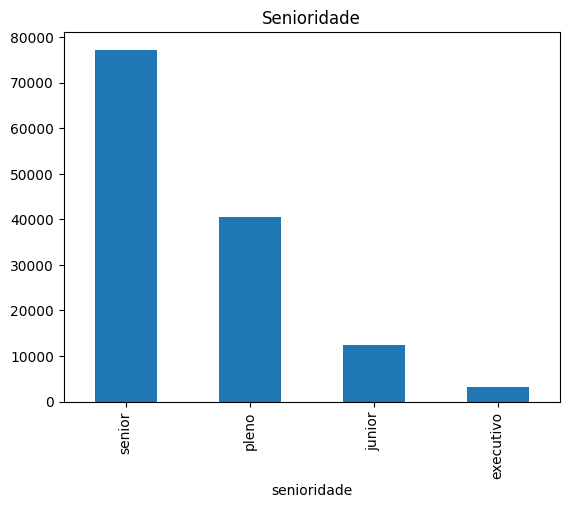

In [103]:
df_limpo['senioridade'].value_counts().plot.bar().set_title('Senioridade')


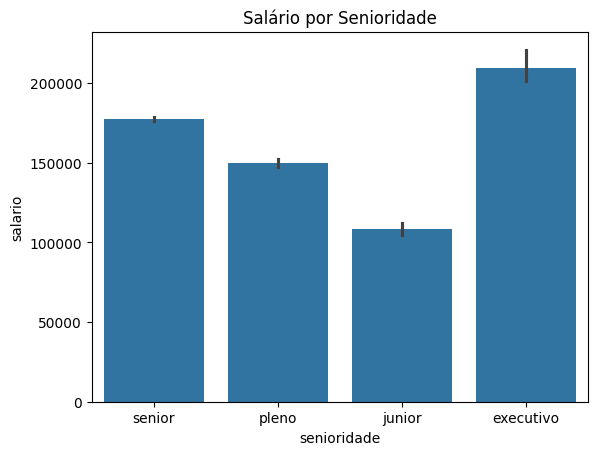

In [104]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(data=df_limpo, x='senioridade', y='salario')
plt.title('Salário por Senioridade')
plt.show()

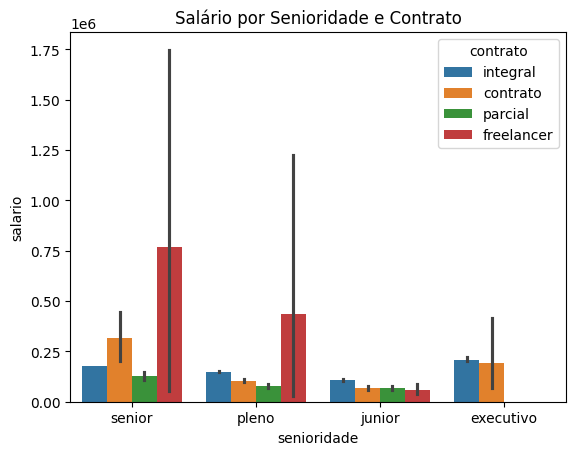

In [105]:
sns.barplot(data=df_limpo, x="senioridade", y="salario", hue="contrato")
plt.title("Salário por Senioridade e Contrato")
plt.show()

In [106]:
df_limpo.head()

,ano,senioridade,contrato,cargo,salario,moeda,usd,residencia,remoto,empresa,tamanho_empresa
0,2025,senior,integral,Solutions Engineer,214000,USD,214000,US,remoto,US,média
1,2025,senior,integral,Solutions Engineer,136000,USD,136000,US,remoto,US,média
2,2025,pleno,integral,Data Engineer,158800,USD,158800,AU,presencial,AU,média
3,2025,pleno,integral,Data Engineer,139200,USD,139200,AU,presencial,AU,média
4,2025,junior,integral,Data Engineer,90000,USD,90000,US,presencial,US,média


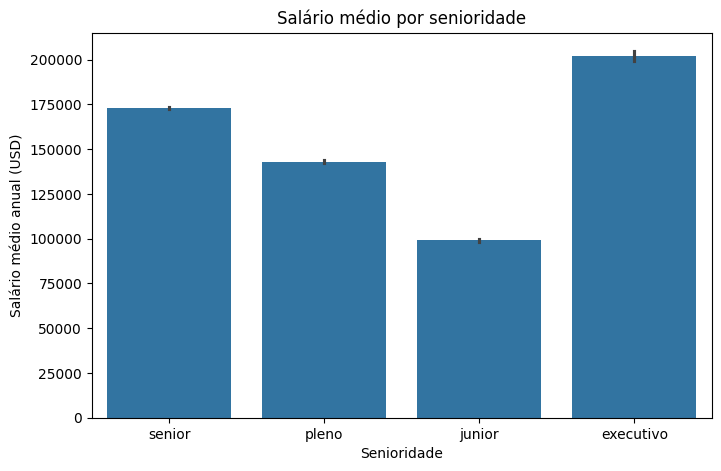

In [108]:

plt.figure(figsize=(8,5))
sns.barplot(data=df_limpo, x='senioridade', y='usd')
plt.title("Salário médio por senioridade")
plt.xlabel("Senioridade")
plt.ylabel("Salário médio anual (USD)")
plt.show()


In [109]:
df_limpo.groupby('senioridade')['usd'].mean().sort_values(ascending=False)

,usd
senioridade,
executivo,202027.667813
senior,172850.838301
pleno,143044.845979
junior,99034.963267


<function matplotlib.pyplot.xlabel(xlabel: 'str', fontdict: 'dict[str, Any] | None' = None, labelpad: 'float | None' = None, *, loc: "Literal['left', 'center', 'right'] | None" = None, **kwargs) -> 'Text'>

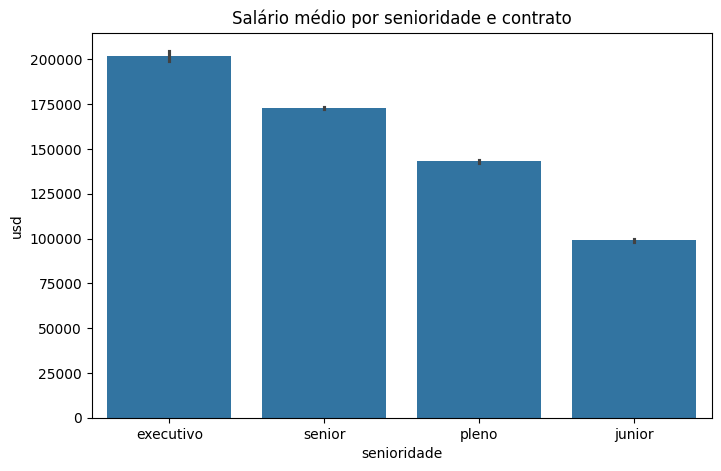

In [110]:
plt.figure(figsize=(8,5))
sns.barplot(data=df_limpo, x="senioridade", y="usd", order=df_limpo.groupby('senioridade')['usd'].mean().sort_values(ascending=False).index)
plt.title("Salário médio por senioridade e contrato")
plt.xlabel

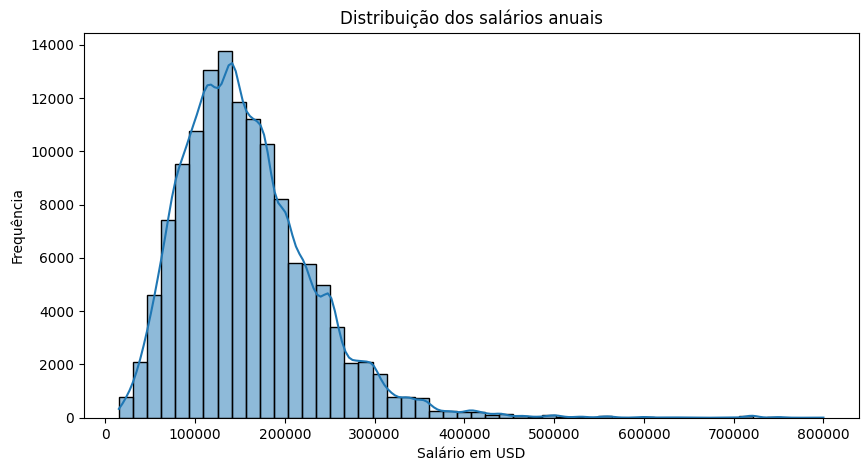

In [113]:
plt.figure(figsize=(10,5))
sns.histplot(df_limpo['usd'], bins = 50, kde=True)
plt.title("Distribuição dos salários anuais")
plt.xlabel("Salário em USD")
plt.ylabel("Frequência")
plt.show()

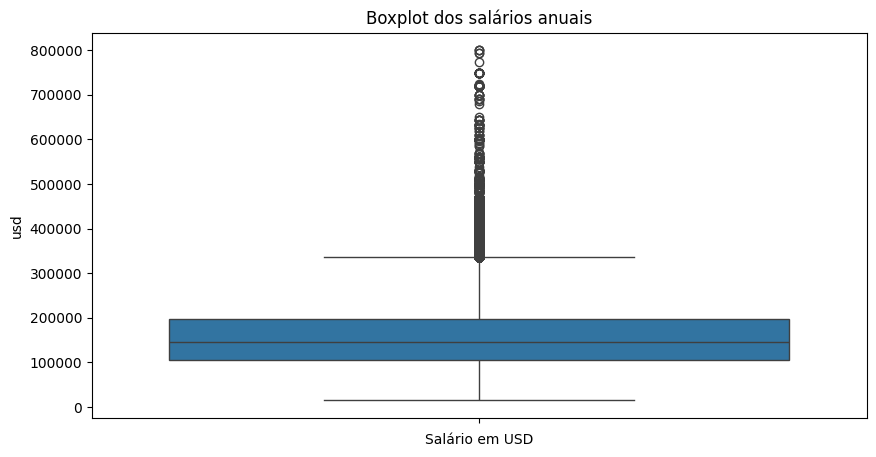

In [117]:
plt.figure(figsize=(10,5))
sns.boxplot(df_limpo['usd'])
plt.title("Boxplot dos salários anuais")
plt.xlabel("Salário em USD")
plt.show()

/tmp/ipython-input-3410885020.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_limpo, x="senioridade", y="usd", order=ordem, palette="Set2")


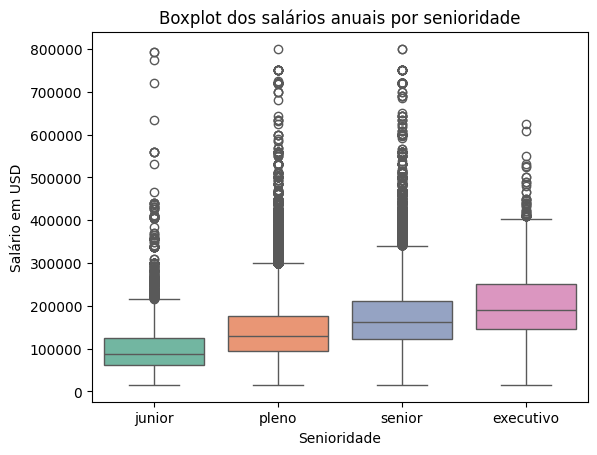

In [120]:
ordem = ["junior", "pleno", "senior", "executivo"]
sns.boxplot(data=df_limpo, x="senioridade", y="usd", order=ordem, palette="Set2")
plt.title("Boxplot dos salários anuais por senioridade")
plt.xlabel("Senioridade")
plt.ylabel("Salário em USD")
plt.show()

In [121]:
import plotly.express as px

# Calcular a média salarial por senioridade
media_salario_senioridade = df_limpo.groupby('senioridade')['usd'].mean().reset_index()

# Definir a ordem desejada das senioridades
ordem = ["junior", "pleno", "senior", "executivo"]
media_salario_senioridade['senioridade'] = pd.Categorical(media_salario_senioridade['senioridade'], categories=ordem, ordered=True)
media_salario_senioridade = media_salario_senioridade.sort_values('senioridade')

# Criar o gráfico de barras interativo
fig = px.bar(
    media_salario_senioridade,
    x='senioridade',
    y='usd',
    title='Média Salarial Anual por Senioridade (USD)',
    labels={
        'senioridade': 'Nível de Senioridade',
        'usd': 'Média Salarial Anual (USD)'
    },
    color='senioridade',
    color_discrete_map={
        'junior': 'skyblue',
        'pleno': 'lightgreen',
        'senior': 'gold',
        'executivo': 'salmon'
    }
)

fig.update_layout(xaxis_title='Senioridade', yaxis_title='Média Salarial Anual (USD)')
fig.show()

In [126]:
remoto_contagem = df_limpo['remoto'].value_counts().reset_index()
remoto_contagem.columns = ['tipo_trabalho', 'quantidade']

fig = px.pie(remoto_contagem,
             names='tipo_trabalho',
             values='quantidade',
             title='Proporção dos tipos de trabalho',
             hole=0.5
          )
fig.update_traces(textinfo='percent+label')
fig.show()

In [127]:
df.head()

,ano,senioridade,contrato,cargo,salario,moeda,usd,residencia,remoto,empresa,tamanho_empresa
0,2025.0,senior,integral,Solutions Engineer,214000,USD,214000,US,remoto,US,média
1,2025.0,senior,integral,Solutions Engineer,136000,USD,136000,US,remoto,US,média
2,2025.0,pleno,integral,Data Engineer,158800,USD,158800,AU,presencial,AU,média
3,2025.0,pleno,integral,Data Engineer,139200,USD,139200,AU,presencial,AU,média
4,2025.0,junior,integral,Data Engineer,90000,USD,90000,US,presencial,US,média


In [128]:
pip install pycountry

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 97.6 MB/s eta 0:00:00


In [129]:

import pycountry

# Função para converter ISO-2 para ISO-3
def iso2_to_iso3(code):
    try:
        return pycountry.countries.get(alpha_2=code).alpha_3
    except:
        return None

# Criar nova coluna com código ISO-3
df_limpo['residencia_iso3'] = df_limpo['residencia'].apply(iso2_to_iso3)

# Calcular média salarial por país (ISO-3)
df_ds = df_limpo[df_limpo['cargo'] == 'Data Scientist']
media_ds_pais = df_ds.groupby('residencia_iso3')['usd'].mean().reset_index()

# Gerar o mapa
fig = px.choropleth(media_ds_pais,
                    locations='residencia_iso3',
                    color='usd',
                    color_continuous_scale='rdylgn',
                    title='Salário médio de Cientista de Dados por país',
                    labels={'usd': 'Salário médio (USD)', 'residencia_iso3': 'País'})

fig.show()

In [130]:
df_limpo.to_csv('dados-aula-final.csv', index=False)